### ***Exploratory Data Analysis On CLeaned AC Dataset***

### ***Column Reference***

Quick map of all 22 columns in `ac_cleaned.parquet` (994 rows). Use this as a reference while exploring.

#### Categorical (3 columns)

| Column | Description |
| --- | --- |
| `brand` | Manufacturer name. 33+ brands (Voltas, LG, Samsung, etc.). |
| `product` | Appliance category. **Constant `"AC"`** today — only ACs scraped. Future-proofed for other appliances. |
| `ac_type` | AC form factor. Two values: `Split` (905) and `Window` (107). |

#### Numeric — Continuous (2 columns)

| Column | Description |
| --- | --- |
| `price` | **TARGET.** Marketplace price in INR. Range: ₹19,990 – ₹86,990. |
| `user_rating` | Customer rating on 5-point scale. Range: 3.15 – 4.75 (narrow band — most ACs rate 4.0+). |

#### Numeric — Discrete (17 columns)

| Column | Description |
| --- | --- |
| `capacity` | AC capacity in tons. Standard sizes: 0.75, 1.0, 1.2, 1.5, 1.6, 1.8, 2.0, 2.5, 3.0. |
| `model_year` | Year of manufacture (extracted from name). **831/994 non-null** (16.4% missing). Range: 2019–2025. |
| `star_rating` | BEE energy rating (1–5). Higher = more efficient. |
| `inverter` | Binary: 1 = inverter tech, 0 = non-inverter. |
| `Dehumidification` | Binary: 1 = has moisture-removal mode. |
| `Turbo Mode` | Binary: 1 = has fast-cooling turbo mode. |
| `Air Swing` | Binary: 1 = has auto air-swing (combines 2-way and 4-way). |
| `Self Diagnosis` | Binary: 1 = AC can self-diagnose faults. |
| `Memory Feature` | Binary: 1 = remembers last settings after power-off. |
| `LED Panel Display` | Binary: 1 = has LED display on the unit. |
| `Night Glow Buttons` | Binary: 1 = backlit remote buttons. |
| `Wi-Fi Connectivity` | Binary: 1 = Wi-Fi enabled. |
| `APP Control` | Binary: 1 = mobile-app controllable. |
| `Auto Clean` | Binary: 1 = self-cleaning mode. |
| `Hidden Panel Display` | Binary: 1 = display hides when idle. |
| `Voice Control` | Binary: 1 = voice-assistant compatible. |
| `PM 2.5 Filter` | Binary: 1 = has PM 2.5 air filter. |

**Total: 22 columns** (3 categorical + 19 numeric: 2 continuous + 17 discrete, including 14 boolean features + inverter).

**Reminders:**
- `name` was dropped from the cleaned dataset after extracting `brand`, `model_year`, `star_rating`
- `product` is constant today — not useful for modeling now, but kept for future multi-appliance support
- `model_year` missingness handled later (brand-median imputation + missing indicator → `age = current_year - model_year`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

In [14]:
# import the data 

data = pd.read_parquet('D:/Study/data_science/underpriced-listing-predictor/data/03.cleaned/ac_cleaned.parquet')

print(data.head(5))

                                                name      brand product  \
0  Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...  Whirlpool      AC   
1  Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...    Carrier      AC   
2  O General ASGG18CGAB-B 1.5 Ton 5 Star Inverter...  O General      AC   
3  Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...      Haier      AC   
4  Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC     Voltas      AC   

   price  rating ac_type  capacity  Dehumidification  Turbo Mode  Air Swing  \
0  24990    4.65   Split       1.5                 0           1          1   
1  22990    4.55   Split       1.5                 1           1          0   
2  67990    4.10   Split       1.5                 1           1          1   
3  37990    4.55   Split       1.5                 1           1          1   
4  22990    4.55   Split       1.5                 1           1          1   

   ...  LED Panel Display  Night Glow Buttons  Wi-Fi Connectivity  \
0  ..

In [3]:
# Basic info about the dataset
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 994 entries, 0 to 993
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  994 non-null    str    
 1   brand                 994 non-null    str    
 2   product               994 non-null    str    
 3   price                 994 non-null    int64  
 4   rating                994 non-null    float32
 5   ac_type               994 non-null    str    
 6   capacity              994 non-null    float32
 7   Dehumidification      994 non-null    int64  
 8   Turbo Mode            994 non-null    int64  
 9   Air Swing             994 non-null    int64  
 10  Self Diagnosis        994 non-null    int64  
 11  Memory Feature        994 non-null    int64  
 12  LED Panel Display     994 non-null    int64  
 13  Night Glow Buttons    994 non-null    int64  
 14  Wi-Fi Connectivity    994 non-null    int64  
 15  APP Control           994 non-null

In [4]:
# Basic stats of each numeric column
print(data.describe())

              price      rating    capacity  Dehumidification  Turbo Mode  \
count    994.000000  994.000000  994.000000        994.000000  994.000000   
mean   40201.465795    4.376409    1.443159          0.875252    0.650905   
std    10546.750948    0.236678    0.322507          0.330600    0.476924   
min    19990.000000    3.150000    0.750000          0.000000    0.000000   
25%    32999.000000    4.150000    1.050000          1.000000    0.000000   
50%    37525.500000    4.400000    1.500000          1.000000    1.000000   
75%    44868.250000    4.600000    1.500000          1.000000    1.000000   
max    86990.000000    4.750000    3.000000          1.000000    1.000000   

        Air Swing  Self Diagnosis  Memory Feature  LED Panel Display  \
count  994.000000      994.000000      994.000000          994.00000   
mean     0.896378        0.467807        0.203219            0.21328   
std      0.304923        0.499214        0.402597            0.40983   
min      0.000000 

### ***Univariate Analysis***

In [18]:
# Describe the column price
data['price'].describe()

count      994.000000
mean     40201.465795
std      10546.750948
min      19990.000000
25%      32999.000000
50%      37525.500000
75%      44868.250000
max      86990.000000
Name: price, dtype: float64

- Mean AC price is 40201
- Price ranges from 20000  to almost 87000 and 75% of the prices are below 45000, that can easily imply the column has outliers
- Check it With Histogram and QQ Plot

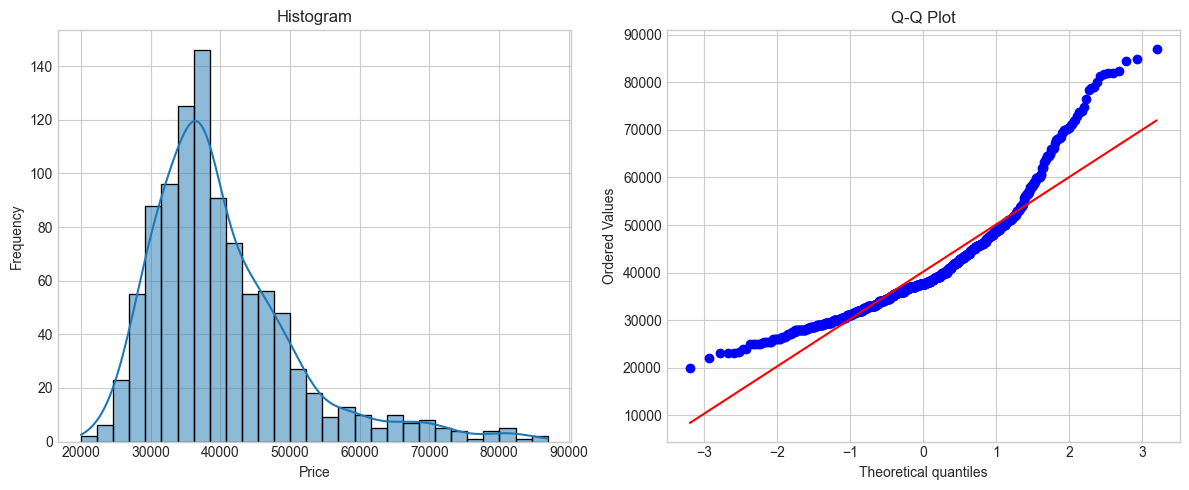

In [23]:
import matplotlib.pyplot as plt
import scipy.stats as stats

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
sns.histplot(data =data , x ='price' , kde=True, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Q-Q Plot
stats.probplot(data['price'], dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

- Histogram shows a right-skewness in the prices.
- QQ Plot plot suggests that the price column is not perfectly normally distributed

**Let us Check the Log transformed prices**

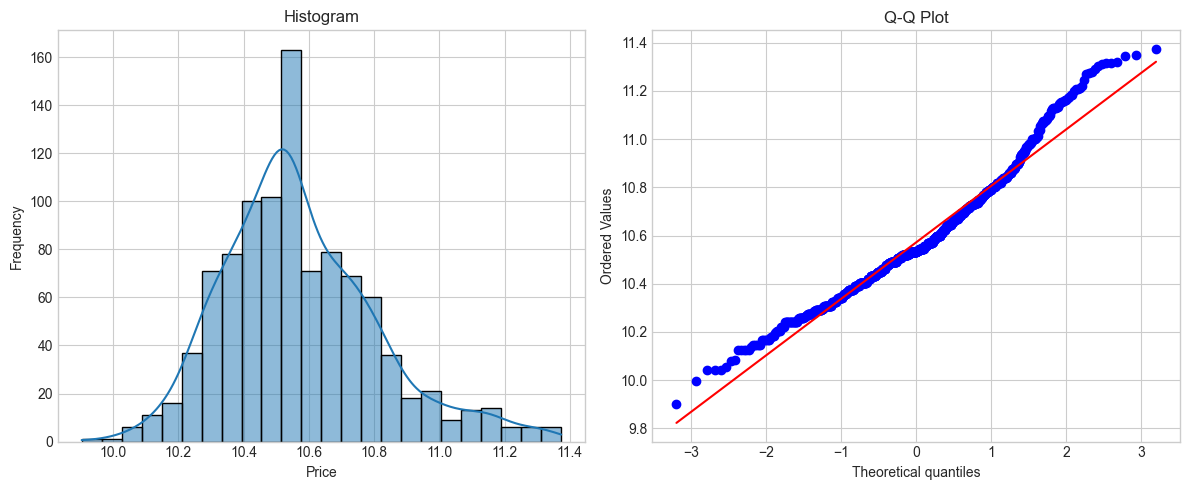

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

log_prices = np.log1p(data['price'])
# Histogram
sns.histplot(x =log_prices , kde=True, ax=axes[0])
axes[0].set_title('Histogram')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

# Q-Q Plot
stats.probplot(log_prices, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

- Clearly the skewness of the data decreased after we did log transformation.      
**Thus We will log transform our prices before training the linear models**

**Box Plots to Look for Outliers**

<Axes: xlabel='price'>

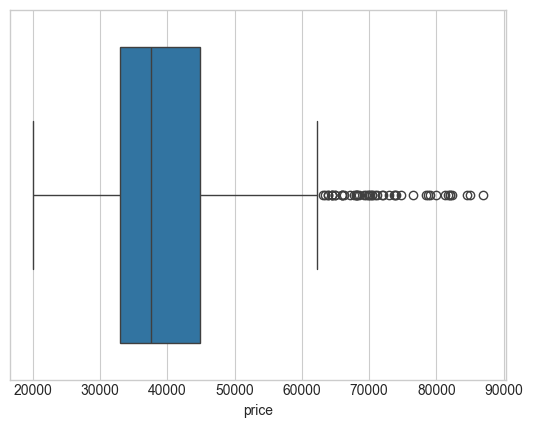

In [20]:
sns.boxplot(data=data , x='price')

In [30]:
# Checking the outlier data
q3 = np.quantile(data['price'],.75)
q1 = np.quantile(data['price'],.25)

lower = q1 - 1.5*(q3-q1)
upper = q3 + 1.5*(q3-q1)

data[((data['price']>=lower) & (data['price']<=upper))]

,name,brand,product,price,rating,ac_type,capacity,Dehumidification,Turbo Mode,Air Swing,...,LED Panel Display,Night Glow Buttons,Wi-Fi Connectivity,APP Control,Auto Clean,Hidden Panel Display,Voice Control,PM 2.5 Filter,inverter,star_rating
0,Whirlpool SAI18B52MCD1 1.5 Ton 5 Star Inverter...,Whirlpool,AC,24990,4.65,Split,1.5,0,1,1,...,0,1,0,0,0,0,0,0,1,5
1,Carrier CAI18ER3R34F0 1.5 Ton 3 Star 2024 Inve...,Carrier,AC,22990,4.55,Split,1.5,1,1,0,...,0,0,0,0,1,1,0,0,1,3
3,Haier HSU18V-POW5BN-INV 1.5 Ton 5 Star 2025 In...,Haier,AC,37990,4.55,Split,1.5,1,1,1,...,0,0,0,0,1,1,0,0,1,5
4,Voltas 183V XAZX 1.5 Ton 3 Star Split Inverter AC,Voltas,AC,22990,4.55,Split,1.5,1,1,1,...,0,1,0,0,0,0,0,0,1,3
5,Panasonic CS/CU-NU18XKYWA 1.5 Ton 5 Star Inver...,Panasonic,AC,29990,4.30,Split,1.5,1,0,1,...,0,1,0,0,0,0,0,0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
989,Blue Star IC512EBTU 1 Ton 5 Star Split Inverte...,Blue Star,AC,38650,4.10,Split,1.0,1,1,1,...,0,0,0,0,0,0,0,0,1,5
990,Hitachi RSNG318HDEAZ2 1.5 Ton 3 Star Split Inv...,Hitachi,AC,37650,4.10,Split,1.5,0,0,0,...,0,0,0,0,0,0,0,0,1,3
991,Samsung AR18TY3QBPU 1.5 Ton 3 Star Split Inver...,Samsung,AC,37388,4.70,Split,1.5,1,1,1,...,0,0,0,0,1,0,0,0,1,3
992,Hitachi RSM318HDDO 1.5 Ton 3 Star 2019 Split AC,Hitachi,AC,37650,4.25,Split,1.5,1,0,0,...,0,1,0,0,0,0,0,0,0,3


Looking at the box plot, we can see several outliers in our data. But these are genuine products with higher prices, so we keep them intact.